In [1]:
import warnings

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data_path   = "/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/driftDatasets/artificial/hyperplane/rotatingHyperplane.data"
# labels_path = "/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/driftDatasets/artificial/hyperplane/rotatingHyperplane.labels"

from pathlib import Path
REL = Path("driftDatasets") / "artificial" / "hyperplane"

# Existing behaviour first: the notebook lives in scripts/, so the repo root is
# one level up. Fall back to searching upward if launched elsewhere.
BASE = Path.cwd().resolve().parents[0] / REL
if not (BASE / "rotatingHyperplane.data").exists():
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (parent / REL / "rotatingHyperplane.data").exists():
            BASE = parent / REL
            break
data_path, labels_path = BASE / "rotatingHyperplane.data", BASE / "rotatingHyperplane.labels"
assert data_path.exists() and labels_path.exists(), f"dataset not found under {BASE}"

X = np.loadtxt(data_path)            # features: a table, one row per instance
y = np.loadtxt(labels_path).astype(int)  # labels: 0 or 1, one per instance

print("Feature table shape:", X.shape)   # (rows, columns) = (instances, features)
print("Labels shape:", y.shape)

Feature table shape: (200000, 10)
Labels shape: (200000,)


In [3]:
print("First 3 rows of features:\n", X[:3])
print("\nNumber of features:", X.shape[1])
print("First 10 labels:", y[:10])
print("Class balance:", np.bincount(y))   # how many of each class

First 3 rows of features:
 [[0.397174 0.347518 0.294057 0.506484 0.115967 0.770536 0.659893 0.156747
  0.378202 0.139763]
 [0.27503  0.075388 0.610592 0.954931 0.274069 0.190202 0.001299 0.683527
  0.48626  0.487515]
 [0.233156 0.889909 0.038327 0.592379 0.655174 0.119839 0.652477 0.984323
  0.206738 0.37465 ]]

Number of features: 10
First 10 labels: [0 0 1 0 0 0 1 0 1 1]
Class balance: [100065  99935]


In [4]:
def mean_abs_shap(shap_values, n_features):
    sv = np.abs(np.array(shap_values))
    feat_axis = [ax for ax, size in enumerate(sv.shape) if size == n_features][-1]
    other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
    return sv.mean(axis=other_axes)

def shap_share(clf, Xs):
    """Normalised mean|SHAP| profile — the vector the L1 signal compares."""
    imp = mean_abs_shap(shap.TreeExplainer(clf).shap_values(Xs), Xs.shape[1])
    return imp / imp.sum()

def mean_dominance(clf, Xs):
    """Mean share of trees voting with the majority. Requires NO labels.

    The harness used frac_not_unanimous. That statistic is useless here: with
    ten continuous features almost no row is unanimous (0.99 at baseline), so
    it saturates at 1.0. The mean still moves, so use the mean on this stream."""
    Xa = np.asarray(Xs, dtype=np.float32)
    p1 = np.stack([clf.classes_[t.predict(Xa).astype(int)]
                   for t in clf.estimators_]).mean(axis=0)
    return float(np.maximum(p1, 1.0 - p1).mean())


In [5]:
def windowed_importance(X, y, window=1000, sample=200, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape

    retrained_imp, frozen_imp, frozen_acc, dominance, centers = [], [], [], [], []
    fixed_model = None

    for w in range(n // window):
        lo, hi = w * window, (w + 1) * window
        Xw, yw = X[lo:hi], y[lo:hi]
        if len(np.unique(yw)) < 2:
            continue

        idx = rng.choice(len(Xw), min(sample, len(Xw)), replace=False)
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                     random_state=seed).fit(Xw, yw)
        retrained_imp.append(shap_share(clf, Xw[idx]))
        centers.append((lo + hi) // 2)

        if fixed_model is None:
            fixed_model = clf                       # deploy window 0, then freeze
            frozen_imp.append(retrained_imp[-1]); frozen_acc.append(np.nan)
        else:
            frozen_imp.append(shap_share(fixed_model, Xw[idx]))
            frozen_acc.append(fixed_model.score(Xw, yw))

        dominance.append(mean_dominance(fixed_model, Xw))

    return (np.array(retrained_imp), np.array(frozen_imp), np.array(frozen_acc),
            np.array(dominance), np.array(centers), fixed_model)


(retrained_imp, frozen_imp, fixed_acc,
 dominance, centers, fixed_model) = windowed_importance(X, y, window=1000)
print("Computed signals for", len(centers), "windows.")


Computed signals for 200 windows.


In [6]:
plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200,
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
CB  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
win = np.arange(len(centers))
d   = X.shape[1]

import pathlib
FIGDIR = pathlib.Path("..") / "figures"
FIGDIR.mkdir(exist_ok=True)


def save(fig, name):
    """dpi=400 keeps >=300 DPI after tight cropping at the 6.0 in text width."""
    fig.tight_layout()
    fig.savefig(FIGDIR / name, dpi=400, bbox_inches="tight")
    print("wrote", FIGDIR / name)


wrote ../figures/fig3_2_swing.png
refitted [0.207 0.109 0.192 0.086 0.417 0.201 0.239 0.148 0.288 0.26 ]
frozen   [0.023 0.013 0.006 0.012 0.026 0.009 0.03  0.029 0.029 0.035]


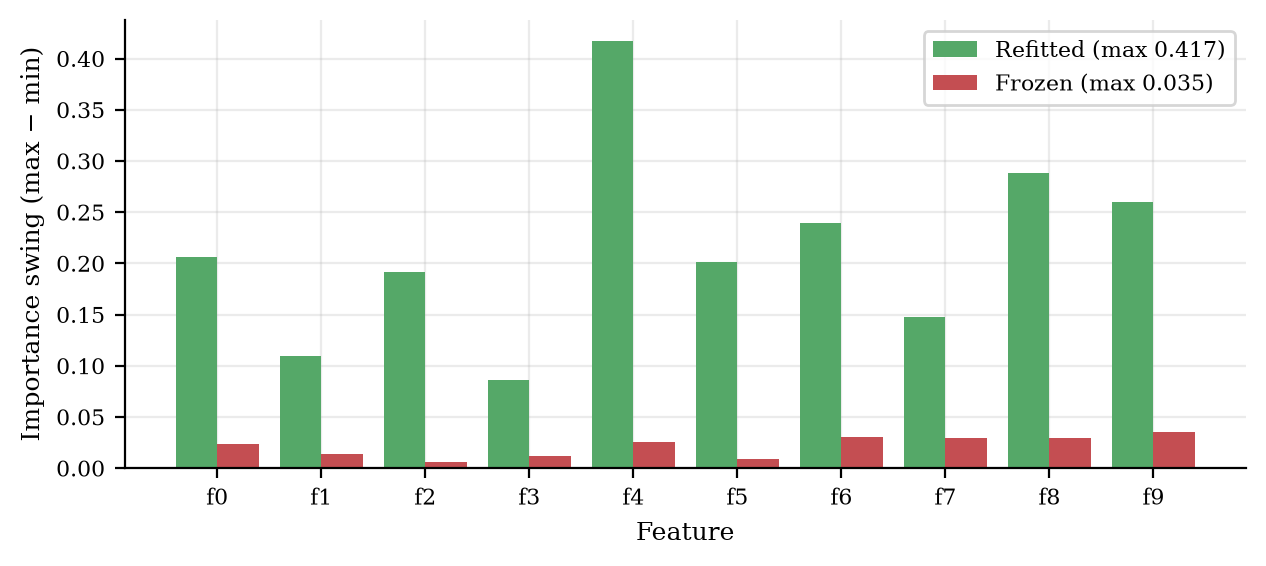

In [7]:
sw_r = retrained_imp.max(0) - retrained_imp.min(0)
sw_f = frozen_imp.max(0)    - frozen_imp.min(0)

fig, ax = plt.subplots(figsize=(6.4, 2.9))
b = np.arange(d)
ax.bar(b - 0.2, sw_r, 0.4, color=CB[2], label=f"Refitted (max {sw_r.max():.3f})")
ax.bar(b + 0.2, sw_f, 0.4, color=CB[3], label=f"Frozen (max {sw_f.max():.3f})")
ax.set_xticks(b); ax.set_xticklabels([f"f{i}" for i in range(d)])
ax.set_xlabel("Feature"); ax.set_ylabel("Importance swing (max − min)")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig3_2_swing.png")
print("refitted", np.round(sw_r, 3)); print("frozen  ", np.round(sw_f, 3))


wrote ../figures/fig3_8_trajectories.png


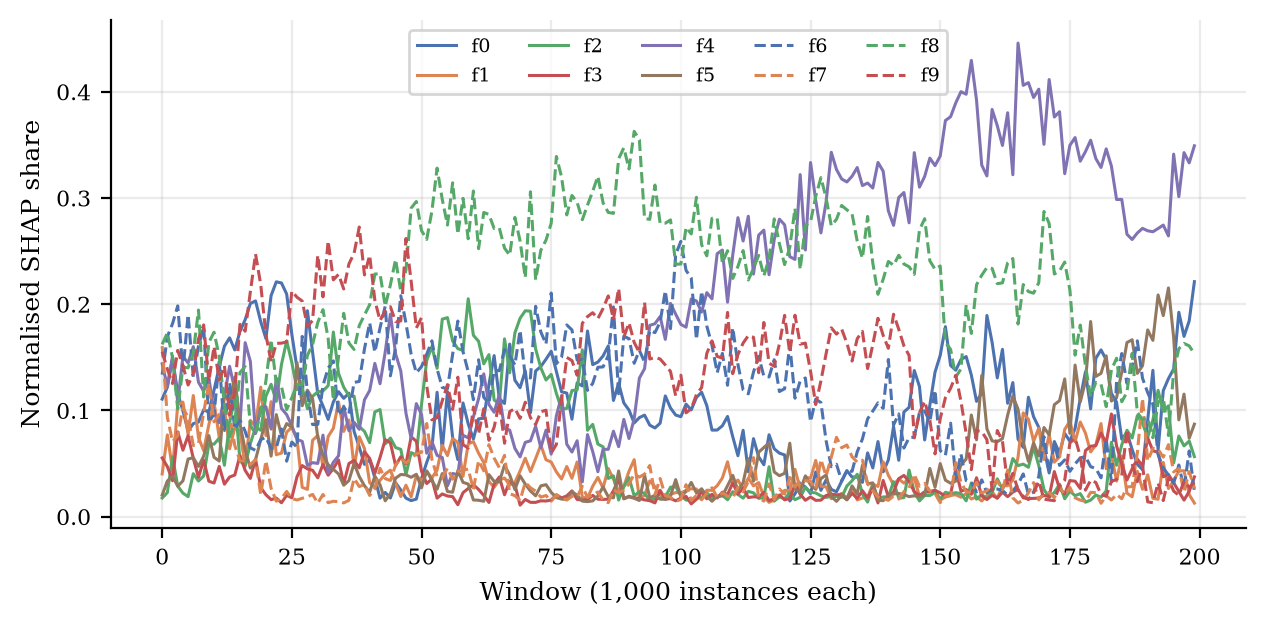

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for i in range(d):
    ax.plot(win, retrained_imp[:, i], lw=1.1, color=CB[i % 6],
            ls=["-", "--", ":"][i // 6 % 3], label=f"f{i}")
ax.set_xlabel("Window (1,000 instances each)"); ax.set_ylabel("Normalised SHAP share")
ax.legend(ncol=5, fontsize=7, loc="upper center")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig3_8_trajectories.png")


In [9]:
SEEDS, W, SAMPLE = range(100), 1000, 200
X0, y0 = X[:W], y[:W]

# Bootstrap window 0 rather than only varying the forest seed. Between two
# windows of the same concept BOTH the sample and the fit differ, so a
# seed-only band measures one of the two components and every candidate
# signal crosses it at window 1.
boot_shap, boot_dom = [], []
for s in SEEDS:
    r  = np.random.default_rng(100 + s)
    bi = r.choice(W, W, replace=True)
    Xb, yb = X0[bi], y0[bi]
    c = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=s).fit(Xb, yb)
    boot_shap.append(shap_share(c, Xb[r.choice(W, SAMPLE, replace=False)]))
    boot_dom.append(mean_dominance(c, Xb))
boot_shap = np.array(boot_shap)

shp_ref  = boot_shap.mean(0)
null_shp = np.abs(boot_shap - shp_ref).sum(1).max()

# In-sample dominance reference. SUPERSEDED as a detection threshold: the
# signal it would be compared against is measured on unseen windows, so this
# reference carries an optimism offset unrelated to drift. Retained only as
# the diagnostic quantity reported in section 3.7.2. No alarm is derived from
# it here; the out-of-bag reference in the calibration cell is authoritative.
dom_ref_insample  = float(np.mean(boot_dom))
null_dom_insample = float(np.max(np.abs(np.array(boot_dom) - dom_ref_insample)))

retr_L1 = np.abs(retrained_imp - shp_ref).sum(1)
froz_L1 = np.abs(frozen_imp    - shp_ref).sum(1)


def first_alarm(sig, thr, persist=3, start=1):
    """start=1 skips window 0, which is the model's own training window."""
    for i in range(start, len(sig) - persist + 1):
        if (sig[i:i + persist] > thr).all():
            return i
    return None


def first_sustained(mask, sustain, start=1):
    """First index where the boolean mask stays True for `sustain` steps."""
    mask = np.asarray(mask, dtype=bool)
    for i in range(start, len(mask) - sustain + 1):
        if mask[i:i + sustain].all():
            return i
    return None


# Deployment-time performance reference, estimated out of bag on window 0.
# This uses no post-deployment window and involves no post-hoc span choice.
# The deployed forest is NOT replaced: the twin is refitted under the identical
# configuration and seed, and its trees and predictions are verified against
# fixed_model before its OOB score is accepted.
if fixed_model is None:
    raise RuntimeError("fixed_model has not been fitted; run the signal cell first")

oob_model = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                   random_state=0, oob_score=True).fit(X0, y0)

same_pred  = bool((oob_model.predict(X) == fixed_model.predict(X)).all())
same_trees = all(np.array_equal(a.tree_.feature, b.tree_.feature) and
                 np.allclose(a.tree_.threshold, b.tree_.threshold)
                 for a, b in zip(oob_model.estimators_, fixed_model.estimators_))
if not (same_pred and same_trees):
    raise RuntimeError("enabling oob_score altered the fit; reference rejected")

ACC_DROP, SUSTAIN = 0.02, 3
ref_acc   = float(oob_model.oob_score_)
threshold = ref_acc - ACC_DROP
t_deg     = first_sustained(fixed_acc < threshold, SUSTAIN)

print(f"fit unchanged      : predictions {same_pred}, trees {same_trees}")
print(f"OOB reference acc  : {ref_acc:.4f}")
print(f"threshold          : {threshold:.4f}")
print(f"degradation window : {t_deg}")
print()
print(f"refitted SHAP null band (in-sample)        : {null_shp:.4f}")
print(f"in-sample dominance reference (diagnostic) : {dom_ref_insample:.4f} "
      f"(band {null_dom_insample:.4f})")

fit unchanged      : predictions True, trees True
OOB reference acc  : 0.8330
threshold          : 0.8130
degradation window : 8

refitted SHAP null band (in-sample)        : 0.1874
in-sample dominance reference (diagnostic) : 0.9372 (band 0.0046)


In [10]:
# RQ3 baseline arm on the primary stream.
# DDM and ADWIN monitor a DEPLOYED model's error stream, so the frozen
# forest fitted on window 0 is the correct source.
#
# Window 0 is that model's own training window and is excluded, which
# matches start=1 in the signal-side first_alarm above.

from river.drift import ADWIN
from river.drift.binary import DDM


# Pylance/runtime guard: the frozen window-0 model must already exist.
if fixed_model is None:
    raise RuntimeError(
        "fixed_model has not been fitted. Run the upstream window-0 "
        "model-fitting cell before this RQ3 baseline cell."
    )


# Binary error stream in chronological instance order:
# 0 = correct prediction, 1 = prediction error.
err = (fixed_model.predict(X[W:]) != y[W:]).astype(int)

print(
    f"frozen error stream: {err.sum():,} / {len(err):,} "
    f"({err.mean():.3f} error rate)\n"
)


def detector_alarms(errors, detector, offset=W, window=W):
    """Every alarm the detector raises, reported in window indices."""
    out = []

    for i, e in enumerate(errors):
        detector.update(int(e))

        if detector.drift_detected:
            out.append((offset + i) // window)

    return out


DET = {}

for dname, det in [
    ("ADWIN", ADWIN()),
    ("DDM", DDM()),
]:
    alarms = detector_alarms(err, det)

    DET[dname] = alarms[0] if alarms else None

    print(
        f"{dname:<6} first alarm: "
        f"{'never' if not alarms else f'window {alarms[0]}':<12}"
        f"total alarms: {len(alarms)}"
    )


# Candidate-signal alarms are NOT reported here. They are calibrated in the
# out-of-bag cell below, and the single consolidated comparison is
# FINAL_ALARMS in the last cell of this notebook.

frozen error stream: 51,557 / 199,000 (0.259 error rate)

ADWIN  first alarm: window 14   total alarms: 8
DDM    first alarm: window 1    total alarms: 2


In [11]:
# NEGATIVE CONTROL / SENSITIVITY ANALYSIS for the baseline detectors.
# Not a false-positive rate: three replicates, no reference distribution.
# Is the DDM window-1 alarm informative, or an artefact of its own
# initialisation? Permuting the error stream preserves the error rate exactly
# and destroys all temporal structure, so an alarm that survives permutation
# is a property of the detector rather than evidence of drift.

ALARM_POS = {}


def alarm_instances(errors, detector, offset=W):
    """Absolute instance index of every alarm."""
    out = []
    for i, e in enumerate(errors):
        detector.update(int(e))
        if detector.drift_detected:
            out.append(offset + i)
    return out

print("frozen accuracy, windows 1-6:", np.round(fixed_acc[1:7], 3))
print(f"stream error rate: {err.mean():.3f}\n")

print(f"{'stream':<16}{'detector':<8}{'first alarm':<28}total")
for sname, e in [("chronological", err)] + \
                [(f"permuted s{s}", np.random.default_rng(s).permutation(err))
                 for s in range(3)]:
    for dname, det in [("ADWIN", ADWIN()), ("DDM", DDM())]:
        a = alarm_instances(e, det)
        ALARM_POS[(sname, dname)] = list(a)
        first = "never" if not a else f"instance {a[0]:,} (window {a[0] // W})"
        print(f"{sname:<16}{dname:<8}{first:<28}{len(a)}")

frozen accuracy, windows 1-6: [0.806 0.83  0.819 0.814 0.826 0.813]
stream error rate: 0.259

stream          detectorfirst alarm                 total
chronological   ADWIN   instance 14,407 (window 14) 8
chronological   DDM     instance 1,748 (window 1)   2
permuted s0     ADWIN   never                       0
permuted s0     DDM     instance 2,173 (window 2)   2
permuted s1     ADWIN   never                       0
permuted s1     DDM     instance 1,157 (window 1)   1
permuted s2     ADWIN   never                       0
permuted s2     DDM     never                       0


In [12]:
# NEGATIVE CONTROL / SENSITIVITY ANALYSIS for the candidate signals.
# Joint (X, y) permutation preserves the empirical feature-label pairs
# but NOT the frozen model's error rate, because a different set of
# instances now constitutes window 0 and a different model is deployed.
# The dominance reference in cell 9 is measured in-sample, on the rows the
# bootstrap forest trained on, while the signal is measured on unseen windows.
# A forest is more unanimous on its own training data, so the reference carries
# an optimism offset unrelated to drift. Calibrate frozen-model signals OOB.

def calibrate(Xs, ys):
    """Match each reference to how its later signal is measured."""
    X0s, y0s = Xs[:W], ys[:W]
    ins, frz, dom = [], [], []
    for s in SEEDS:
        r = np.random.default_rng(100 + s)
        bi = r.choice(W, W, replace=True)
        oob = np.setdiff1d(np.arange(W), bi)
        if len(np.unique(y0s[bi])) < 2:
            raise RuntimeError(f"bootstrap seed {s} produced a one-class fit")
        if len(oob) < SAMPLE:
            raise RuntimeError(f"bootstrap seed {s} produced only {len(oob)} OOB rows")
        c = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                   random_state=s).fit(X0s[bi], y0s[bi])
        ins.append(shap_share(c, X0s[bi][r.choice(W, SAMPLE, replace=False)]))
        frz.append(shap_share(c, X0s[r.choice(oob, SAMPLE, replace=False)]))
        dom.append(mean_dominance(c, X0s[oob]))
    ins, frz, dom = np.array(ins), np.array(frz), np.array(dom)
    if not (np.isfinite(ins).all() and np.isfinite(frz).all() and np.isfinite(dom).all()):
        raise RuntimeError("calibration produced a non-finite value")
    return {"ins_rep": ins, "frz_rep": frz, "dom_rep": dom,
            "ins_ref": ins.mean(0),
            "ins_band": float(np.abs(ins - ins.mean(0)).sum(1).max()),
            "frz_ref": frz.mean(0),
            "frz_band": float(np.abs(frz - frz.mean(0)).sum(1).max()),
            "dom_ref": float(dom.mean()),
            "dom_band": float(np.abs(dom - dom.mean()).max())}

def alarms(cal, sig):
    r_imp, f_imp, dm = sig
    return {"Refitted SHAP L1": first_alarm(
                np.abs(r_imp - cal["ins_ref"]).sum(1), cal["ins_band"]),
            "Frozen SHAP L1": first_alarm(
                np.abs(f_imp - cal["frz_ref"]).sum(1), cal["frz_band"]),
            "Mean vote dominance": first_alarm(
                np.abs(dm - cal["dom_ref"]), cal["dom_band"])}

pi = np.random.default_rng(0).permutation(len(X))
cal_c, cal_p = calibrate(X, y), calibrate(X[pi], y[pi])
perm = windowed_importance(X[pi], y[pi], window=W, sample=SAMPLE)
expected_windows = len(X) // W
if len(retrained_imp) != expected_windows or len(perm[0]) != expected_windows:
    raise RuntimeError("a one-class window was skipped; alarm indices are misaligned")
if not (np.allclose(cal_c["ins_ref"], shp_ref) and
        np.isclose(cal_c["ins_band"], null_shp)):
    raise RuntimeError("refitted-SHAP calibration no longer reproduces cell 9")
A_c = alarms(cal_c, (retrained_imp, frozen_imp, dominance))
A_p = alarms(cal_p, (perm[0], perm[1], perm[3]))

old_dom_dev = np.abs(dominance[1:4] - dom_ref_insample)
oob_dom_dev = np.abs(dominance[1:4] - cal_c["dom_ref"])
print(f"dominance reference   in-sample {dom_ref_insample:.4f}  band {null_dom_insample:.4f}")
print(f"                      out-of-bag {cal_c['dom_ref']:.4f}  band {cal_c['dom_band']:.4f}")
print(f"frozen SHAP band      in-sample {null_shp:.4f} -> out-of-bag {cal_c['frz_band']:.4f}\n")
print("dominance deviations, chronological windows 1-3")
print(f"  from in-sample ref {np.round(old_dom_dev, 4)}  band {null_dom_insample:.4f}")
print(f"  from OOB ref       {np.round(oob_dom_dev, 4)}  band {cal_c['dom_band']:.4f}\n")
print(f"mean frozen accuracy  chronological {np.nanmean(fixed_acc):.3f}  permuted {np.nanmean(perm[2]):.3f}\n")

print(f"{'signal':<24}{'chronological':<16}permuted")
for nm in ("Refitted SHAP L1", "Frozen SHAP L1", "Mean vote dominance"):
    print(f"{nm:<24}{str(A_c[nm]):<16}{A_p[nm]}")

dominance reference   in-sample 0.9372  band 0.0046
                      out-of-bag 0.7244  band 0.0189
frozen SHAP band      in-sample 0.1874 -> out-of-bag 0.2162

dominance deviations, chronological windows 1-3
  from in-sample ref [0.2158 0.2094 0.2093]  band 0.0046
  from OOB ref       [0.0029 0.0034 0.0036]  band 0.0189

mean frozen accuracy  chronological 0.741  permuted 0.781

signal                  chronological   permuted
Refitted SHAP L1        1               106
Frozen SHAP L1          None            None
Mean vote dominance     None            None


wrote ../figures/fig4_2_signals.png


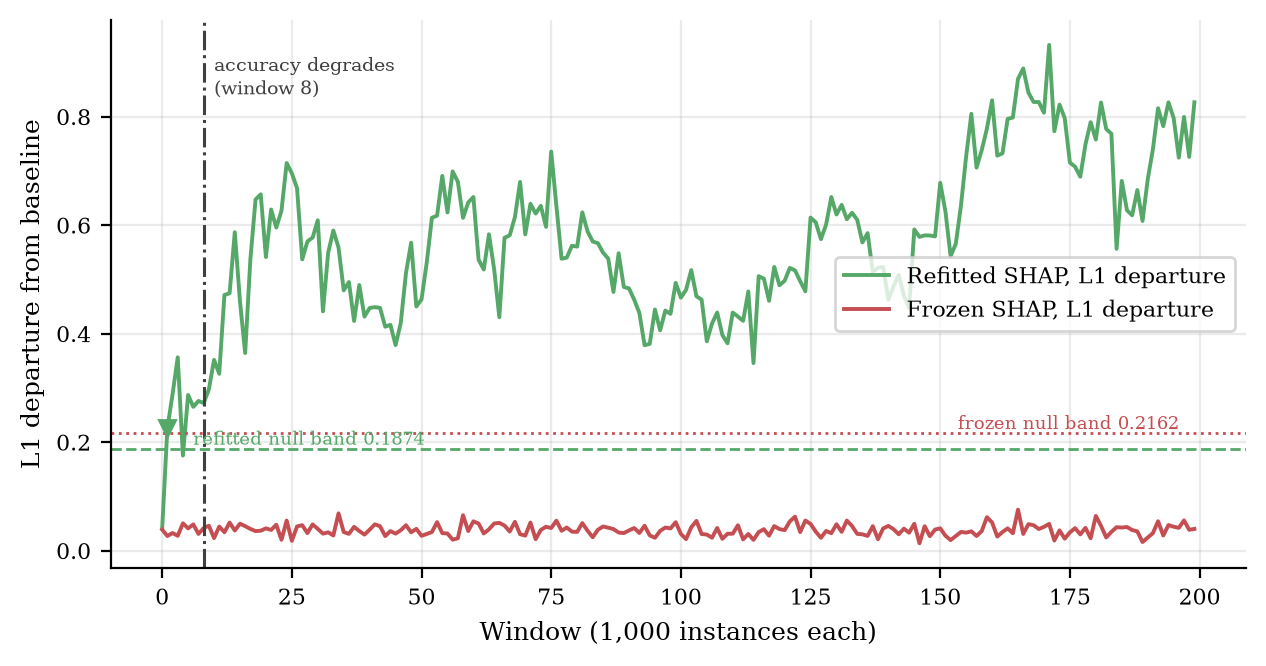

In [13]:
# Regenerated against the out-of-bag calibration. Each signal is drawn against
# the band it is actually tested with -- the refitted signal against its
# in-sample band, the frozen signal against its out-of-bag band -- and the
# degradation line is the OOB-derived point, not the withdrawn post-hoc one.
r_dep = np.abs(retrained_imp - cal_c["ins_ref"]).sum(1)
f_dep = np.abs(frozen_imp    - cal_c["frz_ref"]).sum(1)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(win, r_dep, color=CB[2], lw=1.4, label="Refitted SHAP, L1 departure")
ax.plot(win, f_dep, color=CB[3], lw=1.4, label="Frozen SHAP, L1 departure")
ax.axhline(cal_c["ins_band"], color=CB[2], ls="--", lw=1)
ax.axhline(cal_c["frz_band"], color=CB[3], ls=":",  lw=1)
ax.text(6, cal_c["ins_band"],
        f"refitted null band {cal_c['ins_band']:.4f}",
        fontsize=6.5, color=CB[2], va="bottom", ha="left")

ax.text(196, cal_c["frz_band"],
        f"frozen null band {cal_c['frz_band']:.4f}",
        fontsize=6.5, color=CB[3], va="bottom", ha="right")

# ...

for nm, dep, c in [("Refitted SHAP L1", r_dep, CB[2]),
                   ("Frozen SHAP L1",   f_dep, CB[3])]:
    a = A_c[nm]
    if a is not None:
        ax.plot(a, dep[a], marker="v", color=c, ms=6, clip_on=False)

if t_deg is not None:
    ax.axvline(t_deg, color="0.25", ls="-.", lw=1.1)
    ax.text(t_deg + 2, ax.get_ylim()[1] * 0.86,
            f"accuracy degrades\n(window {t_deg})", fontsize=7, color="0.25")

ax.set_xlabel("Window (1,000 instances each)")
ax.set_ylabel("L1 departure from baseline")
ax.legend(loc="center right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig4_2_signals.png")

In [14]:
# Diagnostic supporting section 3.8. A post-hoc reference span is an analyst
# choice made after seeing the accuracy trace, and the choice moves the
# degradation point. Retained only to justify the out-of-bag reference; none
# of these spans is used for any reported result.
print(f"{'ref span':<12}{'ref_acc':<10}{'t_deg':<8}outside its own span?")
for end in (5, 10, 15, 20):
    ra = np.nanmean(fixed_acc[1:end + 1])
    td = first_sustained(fixed_acc < (ra - ACC_DROP), SUSTAIN)
    print(f"{'1-' + str(end):<12}{ra:<10.4f}{str(td):<8}"
          f"{td is not None and td > end}")
print(f"\nout-of-bag reference, used for all reported results: "
      f"{ref_acc:.4f} -> t_deg {t_deg}")

ref span    ref_acc   t_deg   outside its own span?
1-5         0.8190    9       True
1-10        0.8117    9       False
1-15        0.8015    18      True
1-20        0.7928    18      False

out-of-bag reference, used for all reported results: 0.8330 -> t_deg 8


In [15]:
print(f"threshold {threshold:.4f} (OOB reference {ref_acc:.4f} - {ACC_DROP})")
print("window   accuracy  below threshold")
for w in range(1, 21):
    flag = "yes" if fixed_acc[w] < threshold else ""
    mark = "  <- degradation" if w == t_deg else ""
    print(f"{w:<8} {fixed_acc[w]:.4f}   {flag:<4}{mark}")

threshold 0.8130 (OOB reference 0.8330 - 0.02)
window   accuracy  below threshold
1        0.8060   yes 
2        0.8300       
3        0.8190       
4        0.8140       
5        0.8260       
6        0.8130       
7        0.8230       
8        0.8100   yes   <- degradation
9        0.7890   yes 
10       0.7870   yes 
11       0.7900   yes 
12       0.8000   yes 
13       0.7690   yes 
14       0.7640   yes 
15       0.7820   yes 
16       0.7810   yes 
17       0.7830   yes 
18       0.7670   yes 
19       0.7460   yes 
20       0.7560   yes 


In [16]:
FINAL_ALARMS = {
    "Refitted SHAP L1":    A_c["Refitted SHAP L1"],
    "Frozen SHAP L1":      A_c["Frozen SHAP L1"],
    "Mean vote dominance": A_c["Mean vote dominance"],
    "DDM":                 DET["DDM"],
    "ADWIN":               DET["ADWIN"],
}
NEEDS_LABELS = {"Refitted SHAP L1": "yes", "Frozen SHAP L1": "no",
                "Mean vote dominance": "no", "DDM": "yes", "ADWIN": "yes"}

print("CANONICAL ROTATING-HYPERPLANE RESULT")
print(f"  OOB reference accuracy : {ref_acc:.4f}")
print(f"  degradation threshold  : {threshold:.4f}")
print(f"  degradation window     : {t_deg}")
print()
print(f"{'Method':<24}{'Labels':<9}{'Alarm':<9}Lead")
for name, alarm in FINAL_ALARMS.items():
    lead = "N/A" if alarm is None else t_deg - alarm
    print(f"{name:<24}{NEEDS_LABELS[name]:<9}{str(alarm):<9}{lead}")

# Sensitivity: the degradation point can sit close to its threshold, in which
# case a small shift in the OOB reference moves it by one window and every
# lead with it. Report the margin alongside the table.
if t_deg is not None:
    margin = threshold - fixed_acc[t_deg]
    print(f"\nmargin at the degradation window: {margin:.4f} "
          f"(accuracy {fixed_acc[t_deg]:.4f} vs threshold {threshold:.4f})")
    print("A reference shift larger than this margin moves the degradation "
          "window and every lead by at least one.")

CANONICAL ROTATING-HYPERPLANE RESULT
  OOB reference accuracy : 0.8330
  degradation threshold  : 0.8130
  degradation window     : 8

Method                  Labels   Alarm    Lead
Refitted SHAP L1        yes      1        7
Frozen SHAP L1          no       None     N/A
Mean vote dominance     no       None     N/A
DDM                     yes      1        7
ADWIN                   yes      14       -6

margin at the degradation window: 0.0030 (accuracy 0.8100 vs threshold 0.8130)
A reference shift larger than this margin moves the degradation window and every lead by at least one.


In [17]:
# ---------------------------------------------------------------------------
# CANONICAL VERIFICATION -- rotating hyperplane
# ---------------------------------------------------------------------------
assert X.shape == (200_000, 10) and np.bincount(y).tolist() == [100_065, 99_935]
assert len(centers) == 200 and W == 1000
assert same_pred and same_trees                       # deployed-model guard
assert round(ref_acc, 4) == 0.8330
assert round(threshold, 4) == 0.8130
assert t_deg == 8
assert round(threshold - fixed_acc[t_deg], 4) == 0.0030
assert round(cal_c["ins_band"], 4) == 0.1874
assert round(cal_c["frz_band"], 4) == 0.2162
assert round(cal_c["dom_ref"], 4) == 0.7244
assert round(cal_c["dom_band"], 4) == 0.0189
assert round(dom_ref_insample, 4) == 0.9372
assert round(null_dom_insample, 4) == 0.0046
assert A_c["Refitted SHAP L1"] == 1
assert A_c["Frozen SHAP L1"] is None
assert A_c["Mean vote dominance"] is None
assert A_p["Refitted SHAP L1"] == 106
assert DET["DDM"] == 1 and DET["ADWIN"] == 14
assert ALARM_POS[("chronological", "DDM")][0] == 1_748
assert ALARM_POS[("chronological", "ADWIN")][0] == 14_407
assert len(ALARM_POS[("chronological", "DDM")]) == 2
assert len(ALARM_POS[("chronological", "ADWIN")]) == 8
assert [ALARM_POS[(f"permuted s{s}", "DDM")][:1] for s in range(3)] == [[2173], [1157], []]
assert all(ALARM_POS[(f"permuted s{s}", "ADWIN")] == [] for s in range(3))
print("Rotating-hyperplane canonical values verified.")


Rotating-hyperplane canonical values verified.


wrote ../figures/fig3_11_null_band_bootstrap.png
wrote ../figures/fig3_12_dominance_calibration.png


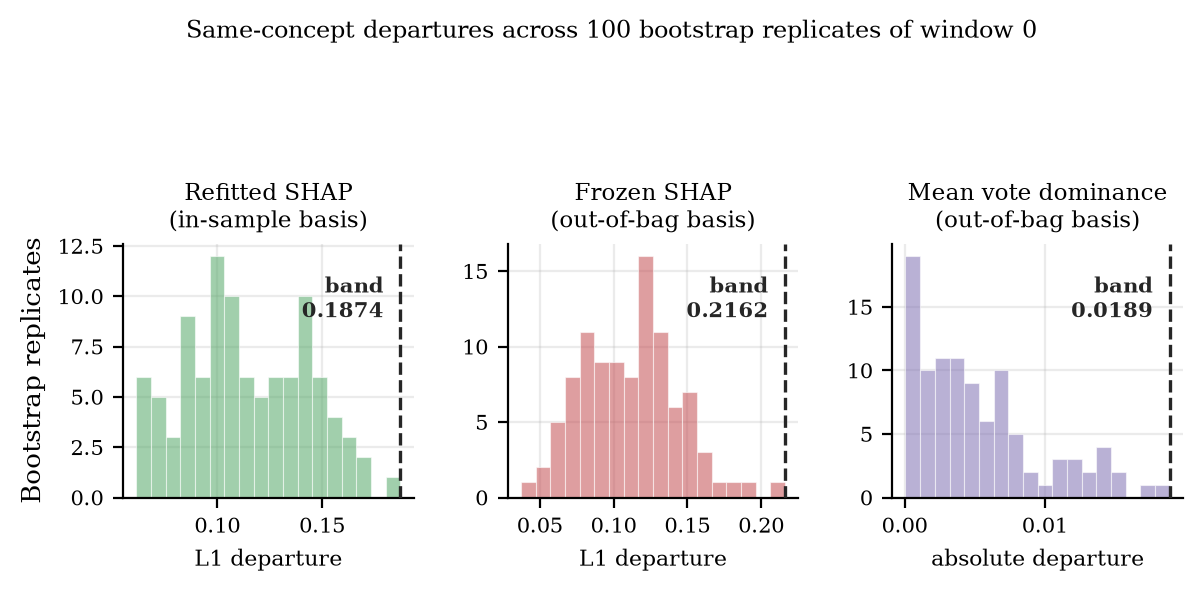

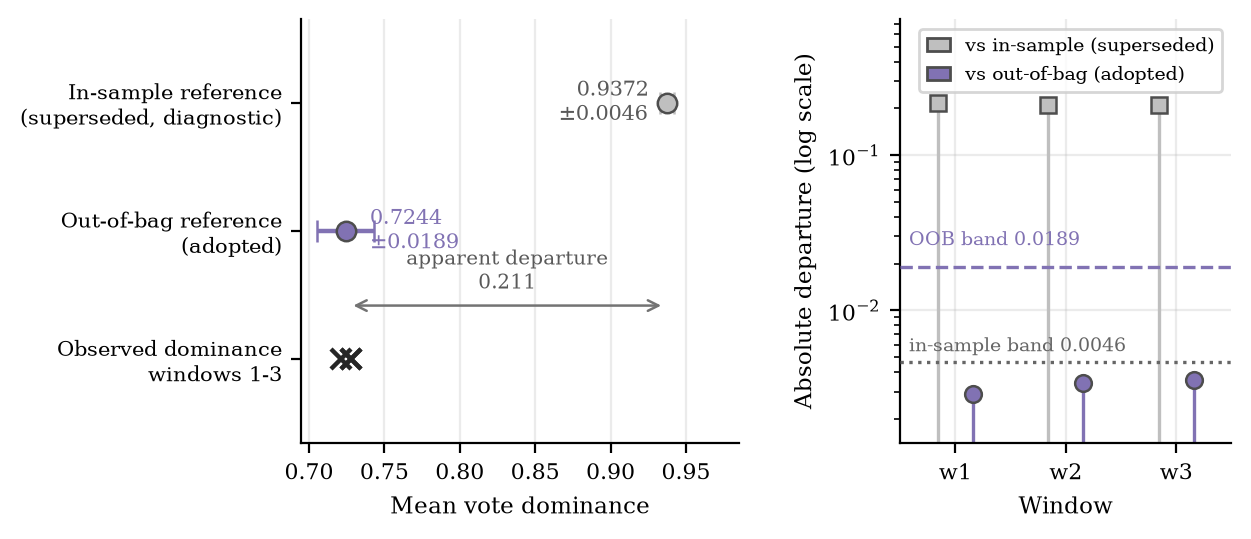

In [18]:
# ---------------------------------------------------------------------------
# DISSERTATION VISUALISATION -- Figures 3.11 and 3.12.  EMPIRICAL.
# Source: cal_c["ins_rep"/"frz_rep"/"dom_rep"] (cell 12), dominance (cell 5),
#         dom_ref_insample / null_dom_insample (cell 9).
# Output: fig3_11_null_band_bootstrap.png, fig3_12_dominance_calibration.png
# ---------------------------------------------------------------------------
from matplotlib.patches import Rectangle, Patch

plt.rcParams.update({"font.size": 9.5, "axes.labelsize": 9.5})
PURPLE = CB[4]


def _despine(a):
    a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    return a


ins_dep = np.abs(cal_c["ins_rep"] - cal_c["ins_ref"]).sum(1)
frz_dep = np.abs(cal_c["frz_rep"] - cal_c["frz_ref"]).sum(1)
dom_dep = np.abs(cal_c["dom_rep"] - np.mean(cal_c["dom_rep"]))

fig, axes = plt.subplots(1, 3, figsize=(6.0, 2.5))
for a, (v, band, col, ttl, xl) in zip(axes, [
        (ins_dep, cal_c["ins_band"], CB[2], "Refitted SHAP\n(in-sample basis)", "L1 departure"),
        (frz_dep, cal_c["frz_band"], CB[3], "Frozen SHAP\n(out-of-bag basis)", "L1 departure"),
        (dom_dep, cal_c["dom_band"], PURPLE, "Mean vote dominance\n(out-of-bag basis)",
         "absolute departure")]):
    a.hist(v, bins=18, color=col, alpha=0.55, edgecolor="white", lw=0.4)
    a.axvline(band, color="0.15", ls="--", lw=1.2, zorder=5)
    a.annotate(f"band\n{band:.4f}", xy=(band, a.get_ylim()[1] * 0.88),
               xytext=(-6, 0), textcoords="offset points", fontsize=7.4,
               ha="right", va="top", color="0.15", fontweight="bold")
    a.set_title(ttl, fontsize=8.2); a.set_xlabel(xl, fontsize=8.0)
    a.tick_params(labelsize=7.4); _despine(a)
axes[0].set_ylabel("Bootstrap replicates")
fig.suptitle("Same-concept departures across 100 bootstrap replicates of window 0",
             fontsize=8.6, y=1.16)
save(fig, "fig3_11_null_band_bootstrap.png")

obs = dominance[1:4]
dev_ins, dev_oob = np.abs(obs - dom_ref_insample), np.abs(obs - cal_c["dom_ref"])
fig, (a, b) = plt.subplots(1, 2, figsize=(6.0, 2.75),
                           gridspec_kw={"width_ratios": [1.32, 1.0], "wspace": 0.42})
a.errorbar(dom_ref_insample, 2, xerr=null_dom_insample, fmt="o", color="0.75",
           ms=7, capsize=4, lw=1.6, mec="0.3", mew=0.9, zorder=4)
a.text(dom_ref_insample - 0.012, 2,
       f"{dom_ref_insample:.4f}\n$\\pm${null_dom_insample:.4f}", fontsize=7.4,
       ha="right", va="center", color="0.35")
a.errorbar(cal_c["dom_ref"], 1, xerr=cal_c["dom_band"], fmt="o", color=PURPLE,
           ms=7, capsize=4, lw=1.6, mec="0.3", mew=0.9, zorder=4)
a.text(cal_c["dom_ref"] + 0.016, 1,
       f"{cal_c['dom_ref']:.4f}\n$\\pm${cal_c['dom_band']:.4f}", fontsize=7.4,
       ha="left", va="center", color=PURPLE)
a.plot(obs, np.zeros(3), "x", color="0.15", ms=7, mew=1.6, zorder=5)
a.annotate("", xy=(dom_ref_insample, 0.42), xytext=(obs.mean(), 0.42),
           arrowprops=dict(arrowstyle="<->", color="0.45", lw=0.9))
a.text((dom_ref_insample + obs.mean()) / 2, 0.50,
       f"apparent departure\n{dev_ins.mean():.3f}", fontsize=7.2, ha="center",
       va="bottom", color="0.35")
a.set_yticks([2, 1, 0])
a.set_yticklabels(["In-sample reference\n(superseded, diagnostic)",
                   "Out-of-bag reference\n(adopted)",
                   "Observed dominance\nwindows 1-3"], fontsize=7.6)
a.set_ylim(-0.65, 2.65); a.set_xlim(0.695, 0.985)
a.set_xlabel("Mean vote dominance", fontsize=8.4)
a.grid(axis="y", visible=False); _despine(a)

xx = np.arange(3)
for xi, di, do in zip(xx, dev_ins, dev_oob):
    b.plot([xi - 0.16] * 2, [1e-3, di], color="0.75", lw=1.2, zorder=2)
    b.plot(xi - 0.16, di, "s", color="0.75", mec="0.3", mew=0.9, ms=6, zorder=4)
    b.plot([xi + 0.16] * 2, [1e-3, do], color=PURPLE, lw=1.2, zorder=2)
    b.plot(xi + 0.16, do, "o", color=PURPLE, mec="0.3", mew=0.9, ms=6, zorder=4)
b.axhline(null_dom_insample, color="0.4", ls=":", lw=1.2, zorder=3)
b.axhline(cal_c["dom_band"], color=PURPLE, ls="--", lw=1.2, zorder=3)
b.text(-0.42, null_dom_insample * 1.10, f"in-sample band {null_dom_insample:.4f}",
       fontsize=6.9, ha="left", va="bottom", color="0.4")
b.text(-0.42, cal_c["dom_band"] * 1.30, f"OOB band {cal_c['dom_band']:.4f}",
       fontsize=6.9, ha="left", va="bottom", color=PURPLE)
b.set_yscale("log"); b.set_ylim(1.4e-3, 0.75); b.set_xlim(-0.5, 2.5)
b.set_xticks(xx); b.set_xticklabels(["w1", "w2", "w3"])
b.set_ylabel("Absolute departure (log scale)", fontsize=8.2)
b.set_xlabel("Window", fontsize=8.4)
b.legend(handles=[Patch(facecolor="0.75", edgecolor="0.3",
                        label="vs in-sample (superseded)"),
                  Patch(facecolor=PURPLE, edgecolor="0.3",
                        label="vs out-of-bag (adopted)")],
         fontsize=6.9, loc="upper right", handlelength=1.2)
_despine(b)
save(fig, "fig3_12_dominance_calibration.png")


wrote ../figures/fig4_3_accuracy_full_trajectory.png
wrote ../figures/fig4_4_degradation_persistence_zoom.png
wrote ../figures/fig4_5_alarm_timing_and_lead.png


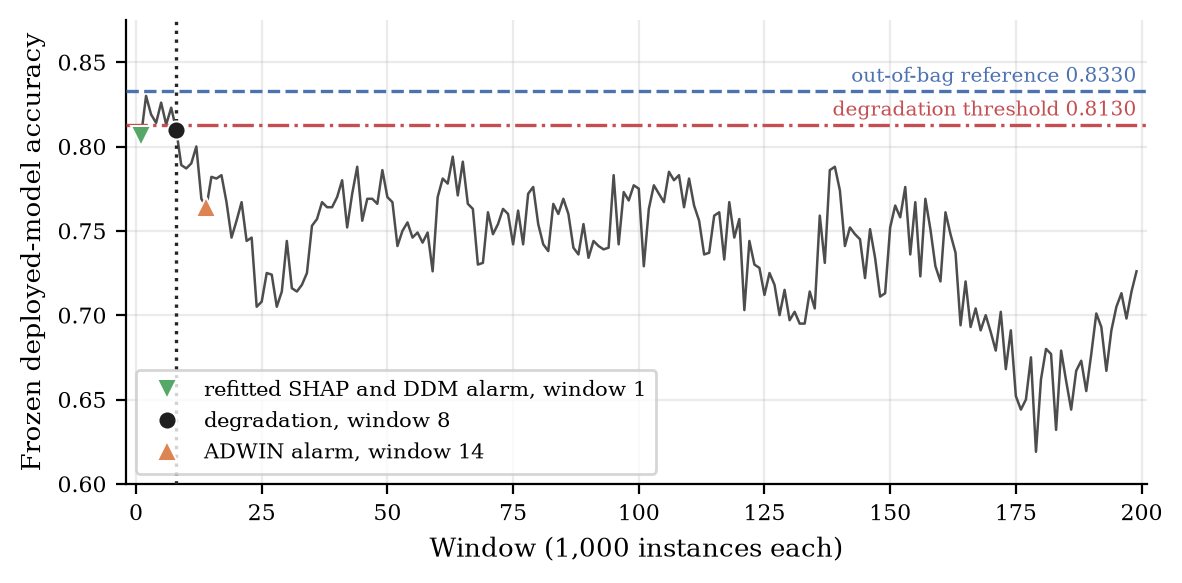

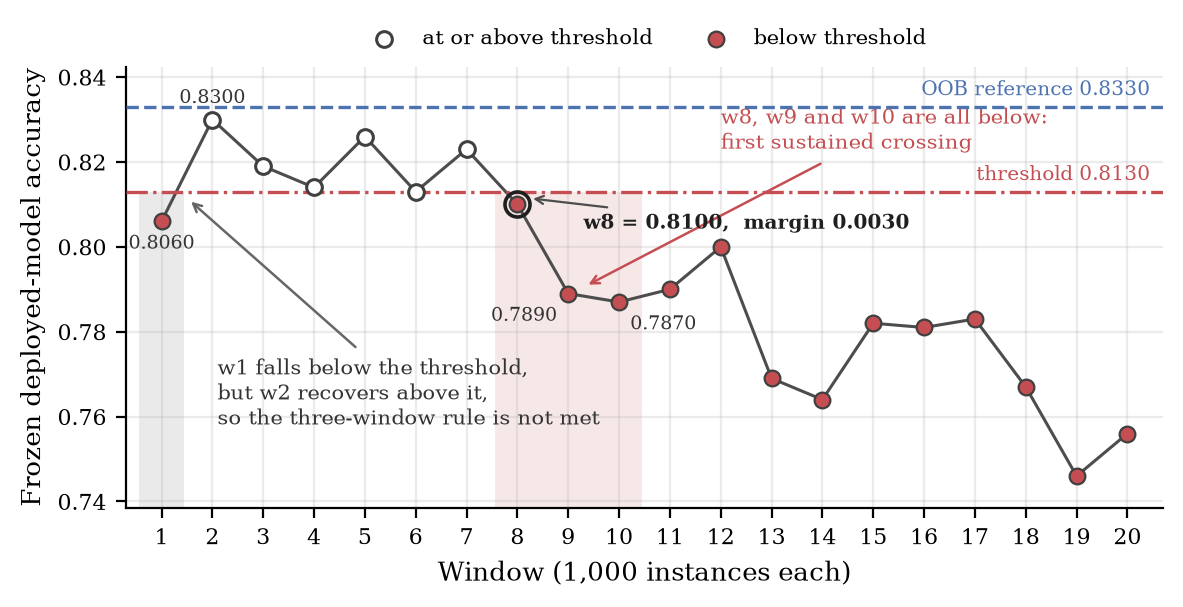

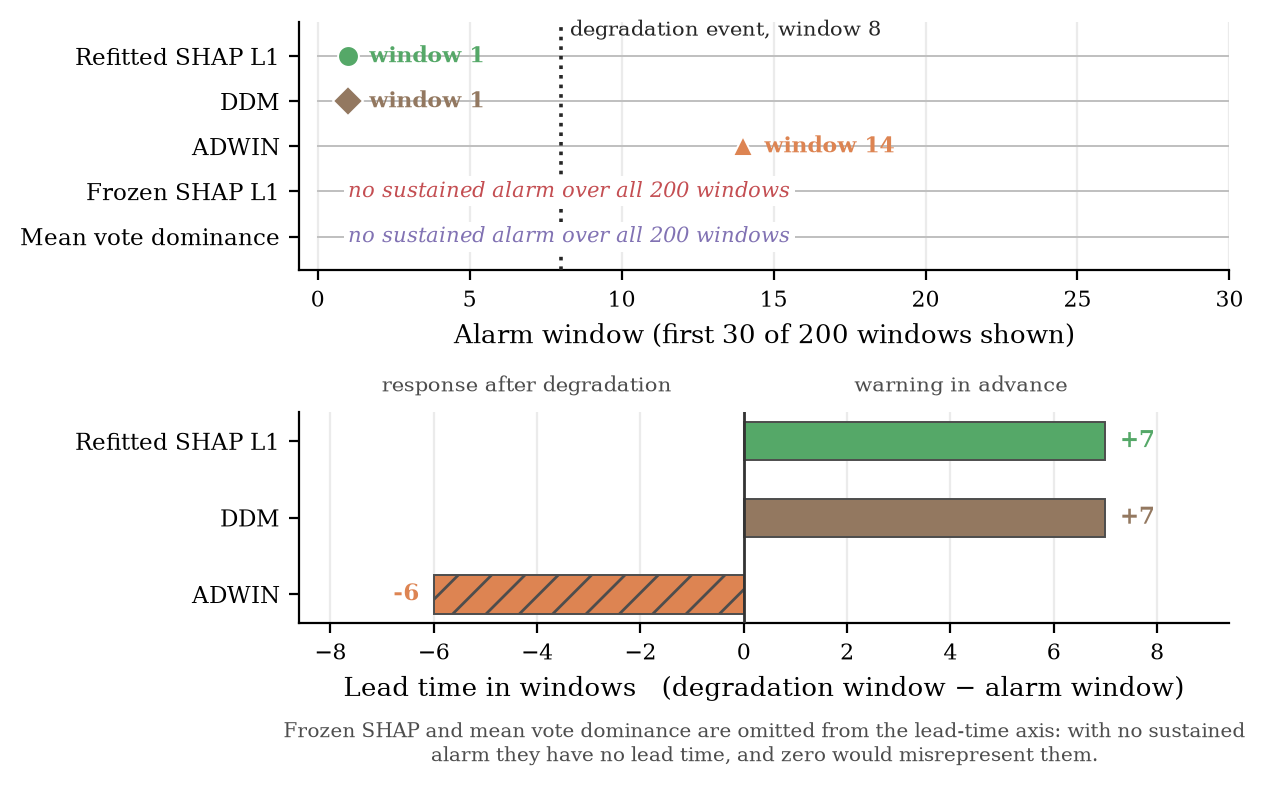

In [19]:
# ---------------------------------------------------------------------------
# DISSERTATION VISUALISATION -- Figures 4.3, 4.4, 4.5.  EMPIRICAL.
# Source: fixed_acc (cell 5), ref_acc / threshold / t_deg (cell 9),
#         A_c (cell 12), DET (cell 10).
# Output: fig4_3_accuracy_full_trajectory.png,
#         fig4_4_degradation_persistence_zoom.png,
#         fig4_5_alarm_timing_and_lead.png
# ---------------------------------------------------------------------------
MARGIN = threshold - fixed_acc[t_deg]

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.plot(win[1:], fixed_acc[1:], color="0.30", lw=0.9, zorder=3)
ax.axhline(ref_acc, color=CB[0], ls="--", lw=1.2, zorder=4)
ax.axhline(threshold, color=CB[3], ls="-.", lw=1.2, zorder=4)
ax.text(199, ref_acc + 0.0025, f"out-of-bag reference {ref_acc:.4f}", fontsize=7.2,
        color=CB[0], ha="right", va="bottom")
ax.text(199, threshold + 0.0025, f"degradation threshold {threshold:.4f}",
        fontsize=7.2, color=CB[3], ha="right", va="bottom")
ax.axvline(t_deg, color="0.15", ls=":", lw=1.2, zorder=5)
ax.plot(1, fixed_acc[1], "v", color=CB[2], ms=7, zorder=6, mec="white", mew=0.7,
        label=f"refitted SHAP and DDM alarm, window {A_c['Refitted SHAP L1']}")
ax.plot(t_deg, fixed_acc[t_deg], "o", color="0.12", ms=6.5, zorder=6, mec="white",
        mew=0.7, label=f"degradation, window {t_deg}")
ax.plot(DET["ADWIN"], fixed_acc[DET["ADWIN"]], "^", color=CB[1], ms=7, zorder=6,
        mec="white", mew=0.7, label=f"ADWIN alarm, window {DET['ADWIN']}")
ax.legend(loc="lower left", fontsize=7.4, borderpad=0.5)
ax.set_xlabel("Window (1,000 instances each)")
ax.set_ylabel("Frozen deployed-model accuracy")
ax.set_xlim(-2, 201); ax.set_ylim(0.60, 0.875)
_despine(ax)
save(fig, "fig4_3_accuracy_full_trajectory.png")

fig, ax = plt.subplots(figsize=(6.0, 3.15))
w20 = np.arange(1, 21); a20 = fixed_acc[1:21]; below = a20 < threshold
LO, HI = 0.7385, 0.8425
ax.add_patch(Rectangle((0.55, LO), 0.9, threshold - LO, facecolor="0.85",
                       alpha=0.55, zorder=0))
ax.add_patch(Rectangle((7.55, LO), 2.9, threshold - LO, facecolor=CB[3],
                       alpha=0.13, zorder=0))
ax.plot(w20, a20, "-", color="0.30", lw=1.1, zorder=3)
ax.scatter(w20[~below], a20[~below], marker="o", s=32, facecolor="white",
           edgecolor="0.25", lw=1.1, zorder=5, label="at or above threshold")
ax.scatter(w20[below], a20[below], marker="o", s=32, facecolor=CB[3],
           edgecolor="0.25", lw=0.8, zorder=5, label="below threshold")
ax.axhline(threshold, color=CB[3], ls="-.", lw=1.2, zorder=4)
ax.axhline(ref_acc, color=CB[0], ls="--", lw=1.2, zorder=4)
ax.text(20.45, threshold + 0.0016, f"threshold {threshold:.4f}", fontsize=7.2,
        color=CB[3], ha="right", va="bottom")
ax.text(20.45, ref_acc + 0.0016, f"OOB reference {ref_acc:.4f}", fontsize=7.2,
        color=CB[0], ha="right", va="bottom")
for wi, dx, dy, ha in [(1, 0.0, -0.0030, "center"), (2, 0.0, 0.0028, "center"),
                       (9, -0.22, -0.0030, "right"), (10, 0.22, -0.0030, "left")]:
    ax.text(wi + dx, fixed_acc[wi] + dy, f"{fixed_acc[wi]:.4f}", fontsize=6.9,
            ha=ha, va=("bottom" if dy > 0 else "top"), color="0.2")
ax.annotate("w1 falls below the threshold,\nbut w2 recovers above it,\n"
            "so the three-window rule is not met",
            xy=(1.5, 0.8115), xytext=(2.1, 0.7565), fontsize=7.4, color="0.2",
            ha="left", va="bottom",
            arrowprops=dict(arrowstyle="->", color="0.4", lw=0.9))
ax.annotate("w8, w9 and w10 are all below:\nfirst sustained crossing",
            xy=(9.3, 0.7905), xytext=(12.0, 0.8215), fontsize=7.4, color=CB[3],
            ha="left", va="bottom",
            arrowprops=dict(arrowstyle="->", color=CB[3], lw=0.9))
ax.plot(t_deg, fixed_acc[t_deg], "o", ms=9, mfc="none", mec="0.12", mew=1.3, zorder=6)
ax.annotate(f"w{t_deg} = {fixed_acc[t_deg]:.4f},  margin {MARGIN:.4f}",
            xy=(8.2, 0.8115), xytext=(9.3, 0.8055), fontsize=7.2, color="0.12",
            ha="left", va="center", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="0.3", lw=0.8))
ax.set_xticks(w20)
ax.set_xlabel("Window (1,000 instances each)")
ax.set_ylabel("Frozen deployed-model accuracy")
ax.set_xlim(0.3, 20.7); ax.set_ylim(LO, HI)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=2, fontsize=7.6,
          frameon=False)
_despine(ax)
save(fig, "fig4_4_degradation_persistence_zoom.png")

ROWS = [("Refitted SHAP L1", A_c["Refitted SHAP L1"], CB[2], "o"),
        ("DDM", DET["DDM"], "#937860", "D"),
        ("ADWIN", DET["ADWIN"], CB[1], "^"),
        ("Frozen SHAP L1", A_c["Frozen SHAP L1"], CB[3], "v"),
        ("Mean vote dominance", A_c["Mean vote dominance"], CB[4], "P")]
fig, (a, b) = plt.subplots(2, 1, figsize=(6.0, 3.9),
                           gridspec_kw={"height_ratios": [1.0, 0.85], "hspace": 0.62})
for k, (nm, al, col, mk) in enumerate(ROWS):
    yy = len(ROWS) - 1 - k
    a.plot([0, 30], [yy, yy], color="0.75", lw=0.7, zorder=1)
    if al is None:
        a.text(1.0, yy, f"no sustained alarm over all {len(centers)} windows",
               fontsize=7.6, va="center", ha="left", color=col, fontstyle="italic",
               zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=1.6))
    else:
        a.plot(al, yy, marker=mk, color=col, ms=7.5, zorder=4, mec="white", mew=0.7)
        a.text(al + 0.7, yy, f"window {al}", fontsize=7.8, va="center", ha="left",
               color=col, fontweight="bold")
a.axvline(t_deg, color="0.15", ls=":", lw=1.3, zorder=3)
a.text(t_deg + 0.3, len(ROWS) - 0.42, f"degradation event, window {t_deg}",
       fontsize=7.6, color="0.15", ha="left", va="center")
a.set_yticks(range(len(ROWS)))
a.set_yticklabels([r[0] for r in reversed(ROWS)], fontsize=8.2)
a.set_ylim(-0.75, len(ROWS) - 0.25); a.set_xlim(-0.6, 30)
a.set_xlabel(f"Alarm window (first 30 of {len(centers)} windows shown)")
a.grid(axis="y", visible=False); _despine(a)

named = [r for r in ROWS if r[1] is not None]
yv = np.arange(len(named))[::-1]
for yy, (nm, al, col, mk) in zip(yv, named):
    lead = t_deg - al
    b.barh(yy, lead, height=0.5, color=col, edgecolor="0.3", lw=0.7,
           hatch=("" if lead > 0 else "//"), zorder=3)
    b.text(lead + (0.28 if lead > 0 else -0.28), yy, f"{lead:+d}", fontsize=8.2,
           va="center", ha=("left" if lead > 0 else "right"), color=col,
           fontweight="bold")
b.axvline(0, color="0.2", lw=1.0, zorder=4)
b.set_yticks(yv); b.set_yticklabels([n[0] for n in named], fontsize=8.2)
b.set_xlim(-8.6, 9.4)
b.set_xlabel("Lead time in windows   (degradation window $-$ alarm window)")
b.text(4.2, len(named) - 0.35, "warning in advance", fontsize=7.4, color="0.3",
       ha="center")
b.text(-4.2, len(named) - 0.35, "response after degradation", fontsize=7.4,
       color="0.3", ha="center")
b.grid(axis="y", visible=False); _despine(b)
b.text(0.5, -0.46, "Frozen SHAP and mean vote dominance are omitted from the "
       "lead-time axis: with no sustained\nalarm they have no lead time, and zero "
       "would misrepresent them.", fontsize=7.2, color="0.3", ha="center",
       va="top", transform=b.transAxes)
save(fig, "fig4_5_alarm_timing_and_lead.png")


wrote ../figures/fig4_6_detector_alarm_positions.png
wrote ../figures/fig4_7_negative_controls.png

All dissertation figures regenerated at publication quality.


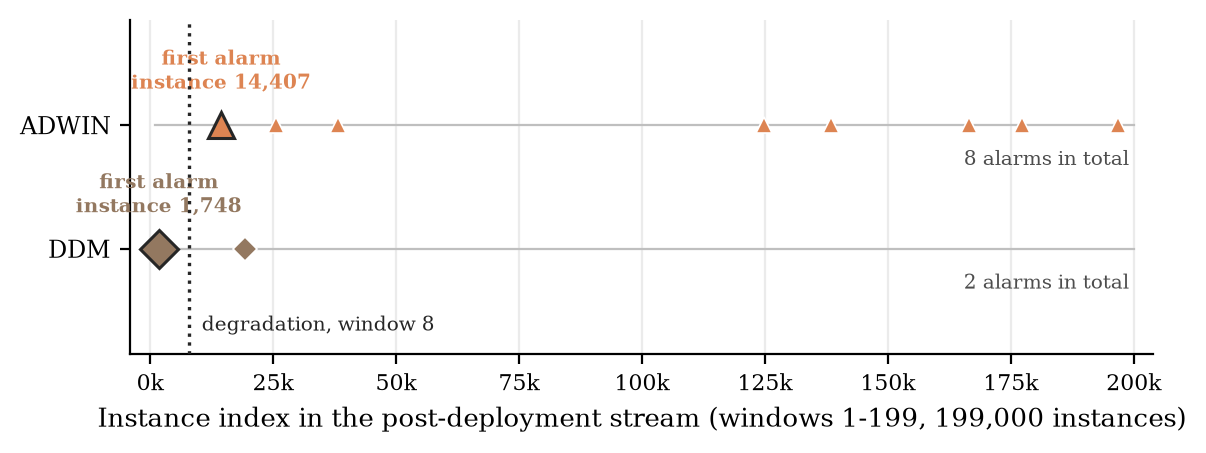

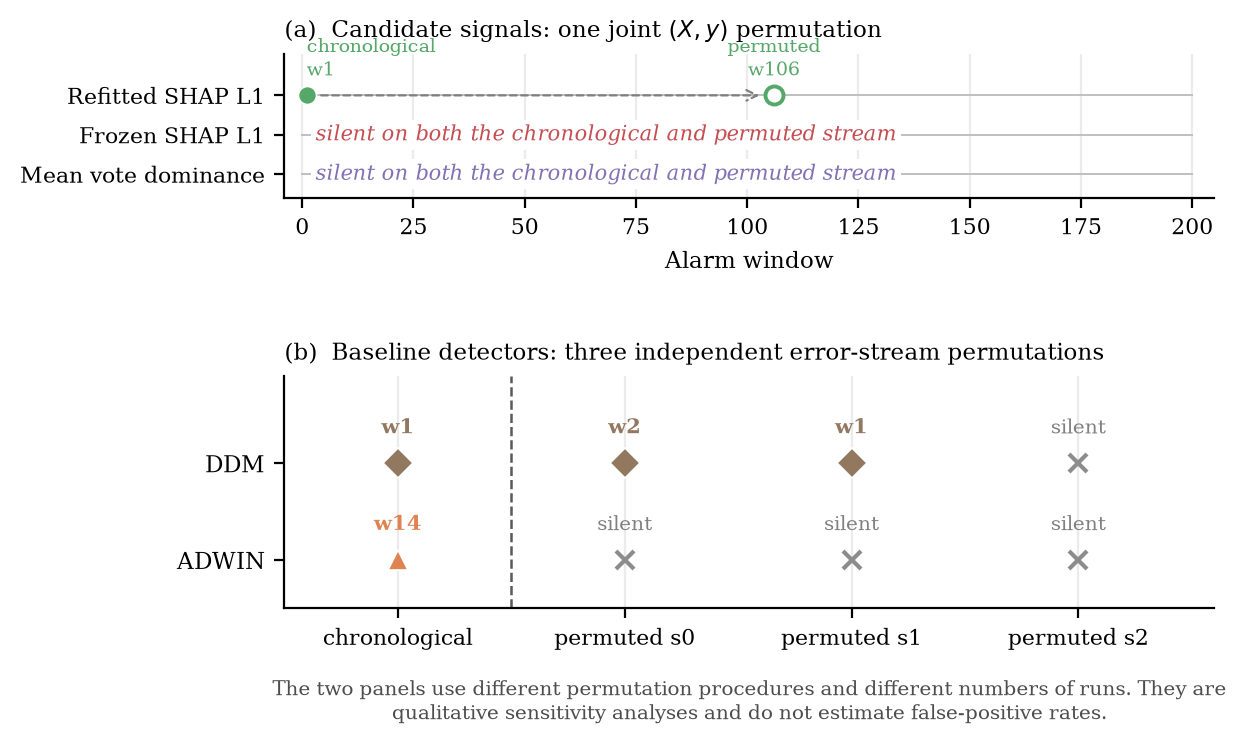

In [20]:
# ---------------------------------------------------------------------------
# DISSERTATION VISUALISATION -- Figures 4.6 and 4.7.  EMPIRICAL.
# Source: ALARM_POS (cell 11), A_c / A_p (cell 12).
# Output: fig4_6_detector_alarm_positions.png, fig4_7_negative_controls.png
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.0, 2.35))
LANES = [("ADWIN", ALARM_POS[("chronological", "ADWIN")], CB[1], "^"),
         ("DDM", ALARM_POS[("chronological", "DDM")], "#937860", "D")]
for k, (nm, pos, col, mk) in enumerate(LANES):
    yy = len(LANES) - 1 - k
    ax.plot([W, len(X)], [yy, yy], color="0.75", lw=0.8, zorder=1)
    ax.plot(pos, np.full(len(pos), yy), marker=mk, ls="none", color=col, ms=6.0,
            mec="white", mew=0.6, zorder=4)
    ax.plot(pos[0], yy, marker=mk, ls="none", color=col, ms=9.5, mec="0.15",
            mew=1.1, zorder=5)
    ax.text(pos[0], yy + 0.24, f"first alarm\ninstance {pos[0]:,}", fontsize=7.2,
            ha="center", va="bottom", color=col, fontweight="bold")
    ax.text(len(X) - W, yy - 0.20, f"{len(pos)} alarms in total", fontsize=7.2,
            ha="right", va="top", color="0.3")
ax.axvline(t_deg * W, color="0.15", ls=":", lw=1.2, zorder=3)
ax.text(t_deg * W + 2500, -0.62, f"degradation, window {t_deg}", fontsize=7.3,
        color="0.15", ha="left", va="center")
ax.set_yticks(range(len(LANES)))
ax.set_yticklabels([l[0] for l in reversed(LANES)], fontsize=8.6)
ax.set_ylim(-0.85, len(LANES) - 0.15); ax.set_xlim(-4000, len(X) + 4000)
ax.set_xticks(np.arange(0, len(X) + 1, 25000))
ax.set_xticklabels([f"{v//1000}k" for v in np.arange(0, len(X) + 1, 25000)])
ax.set_xlabel(f"Instance index in the post-deployment stream "
              f"(windows 1-{len(centers)-1}, {len(X)-W:,} instances)")
ax.grid(axis="y", visible=False); _despine(ax)
save(fig, "fig4_6_detector_alarm_positions.png")

fig, (a, b) = plt.subplots(2, 1, figsize=(6.0, 3.6),
                           gridspec_kw={"height_ratios": [0.62, 1.0], "hspace": 0.95})
a.set_title("(a)  Candidate signals: one joint $(X, y)$ permutation", fontsize=8.4,
            loc="left", pad=6)
SIGS = [("Refitted SHAP L1", CB[2]), ("Frozen SHAP L1", CB[3]),
        ("Mean vote dominance", CB[4])]
for k, (nm, col) in enumerate(SIGS):
    yy = len(SIGS) - 1 - k
    ch, pm = A_c[nm], A_p[nm]
    a.plot([0, len(centers)], [yy, yy], color="0.75", lw=0.7, zorder=1)
    if ch is None:
        a.text(3, yy, "silent on both the chronological and permuted stream",
               fontsize=7.4, va="center", ha="left", color=col, fontstyle="italic",
               zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=1.6))
    else:
        a.plot(ch, yy, "o", color=col, ms=6.5, mec="white", mew=0.6, zorder=4)
        a.plot(pm, yy, "o", color="white", ms=6.5, mec=col, mew=1.4, zorder=4)
        a.annotate("", xy=(pm - 2, yy), xytext=(ch + 2, yy),
                   arrowprops=dict(arrowstyle="->", color="0.5", lw=0.8,
                                   linestyle=(0, (3, 2))))
        a.text(ch, yy + 0.34, f"chronological\nw{ch}", fontsize=7.0, ha="left",
               va="bottom", color=col)
        a.text(pm, yy + 0.34, f"permuted\nw{pm}", fontsize=7.0, ha="center",
               va="bottom", color=col)
a.set_yticks(range(len(SIGS)))
a.set_yticklabels([s[0] for s in reversed(SIGS)], fontsize=8.0)
a.set_ylim(-0.6, len(SIGS) + 0.05); a.set_xlim(-4, len(centers) + 5)
a.set_xlabel("Alarm window", fontsize=8.2)
a.grid(axis="y", visible=False); _despine(a)

b.set_title("(b)  Baseline detectors: three independent error-stream permutations",
            fontsize=8.4, loc="left", pad=6)
STREAMS = ["chronological", "permuted s0", "permuted s1", "permuted s2"]
for k, (dn, col, mk) in enumerate([("DDM", "#937860", "D"), ("ADWIN", CB[1], "^")]):
    yy = 1 - k
    for j, sn in enumerate(STREAMS):
        pos = ALARM_POS[(sn, dn)]
        if pos:
            b.plot(j, yy, marker=mk, color=col, ms=7.5, mec="white", mew=0.6, zorder=4)
            b.text(j, yy + 0.26, f"w{pos[0] // W}", fontsize=7.6, ha="center",
                   va="bottom", color=col, fontweight="bold")
        else:
            b.plot(j, yy, marker="x", color="0.55", ms=6.5, mew=1.5, zorder=4)
            b.text(j, yy + 0.26, "silent", fontsize=7.2, ha="center", va="bottom",
                   color="0.5")
b.axvline(0.5, color="0.35", ls="--", lw=0.9)
b.set_xticks(range(len(STREAMS))); b.set_xticklabels(STREAMS, fontsize=7.8)
b.set_yticks([0, 1]); b.set_yticklabels(["ADWIN", "DDM"], fontsize=8.4)
b.set_xlim(-0.5, len(STREAMS) - 0.4); b.set_ylim(-0.5, 1.9)
b.grid(axis="y", visible=False); _despine(b)
b.text(0.5, -0.30, "The two panels use different permutation procedures and "
       "different numbers of runs. They are\nqualitative sensitivity analyses and "
       "do not estimate false-positive rates.", fontsize=7.2, color="0.3",
       ha="center", va="top", transform=b.transAxes)
save(fig, "fig4_7_negative_controls.png")
print("\nAll dissertation figures regenerated at publication quality.")
